# **Formative 1: Building a Pipeline for Time Series Data**

### **Working with Time Series Data**

### Introduction

In this project, we are going to create a time-series forecasting pipeline to forecast the Walmart Store Sales data provided by Kaggle. The idea is to predict the weekly sales of a store based on the sales pattern of the store and the economic and environment drivers around the store, the type of forecast that a retailer uses to help them manage their stock, staff and promotions.

The data is available in 3 datafiles, merged together:

Our target, `Weekly_Sales` exists in the CSV file train.csv which contains weekly sales for each store and department.
- the store-level variables are in features.csv, these variables include five promotional markdown columns, unemployment, CPI, temperature, and fuel price all of which are stored on label level and vary weekly.
- stores.csv, type and size of the stores.

We append `features` and `stores` to the preceeding `train`, thus the sale data for every store is included next to the conditions of the store for that week. Then we discard all 45 stores and represent all of the departments of one single store with one unit of time per week and do trend, seasonality and lag analysis on that one unit of time.

This is the kind of data that's well suited to the task; there's a clear weekly time stamp, there's a real business target, there are multiple variables that are measured over time, and there's nearly three years of data, that's long enough to see the trend and a definite yearly (holiday) seasonality. That allows us to process along the entire pipeline: address real-world missing data, build a feature for lagged data points and moving averages, and check if the changes in the outside variables or the sales history itself are the determinants of the sales forecast.

*Source of the dataset: https://www.kaggle.com/c/walmart-recruiting-store-sales-forecasting/data*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# **A. Understanding the dataset**

## Step 1: Loading the dataset

In [2]:
train_df = pd.read_csv('/content/train.csv')
stores_df = pd.read_csv('/content/stores.csv')
features_df = pd.read_csv('/content/features.csv')

## 1.1. Playing around with the dataset
Understanding the initial format of the dataset by running some commands like ```pandas.info()``` to be able to take meaningful decisions. This will help us get the glimpse of what dataset we are going to work with, the columns type, and the shape of the dataset

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [4]:
stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [5]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


#/!\ The main take after step 1
Now, we understand our dataset, the shape, and the datatypes of the columns. Next steps:
*   to convert the date which has type of object to datetime type

*   Merge the three datasets; Train, Store, and Features



## Step 2: Converting the date into correct date format

In [6]:
# Converting the date from the object datatype to into the real dates
train_df['Date'] = pd.to_datetime(train_df['Date'])
features_df['Date'] = pd.to_datetime(features_df['Date'])

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB


In [8]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[ns]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     4032 non-null   float64       
 5   MarkDown2     2921 non-null   float64       
 6   MarkDown3     3613 non-null   float64       
 7   MarkDown4     3464 non-null   float64       
 8   MarkDown5     4050 non-null   float64       
 9   CPI           7605 non-null   float64       
 10  Unemployment  7605 non-null   float64       
 11  IsHoliday     8190 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(9), int64(1)
memory usage: 712.0 KB


#/!\ The main take after step 2
From the above, finally date is now of a type ```datetime64[ns]```, better for time series implementations

## Step3: Merge sales + variables + store info (Train, Stores, and Features dataset)

## 3.1. Playing around with the dataset
To better know how to merge them, we first need to learn the columns, and what to follow while merging

In [9]:
train_df.shape, features_df.shape, stores_df.shape

((421570, 5), (8190, 12), (45, 3))

In [10]:
train_df.head(150)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
145,1,2,2010-02-19,47928.89,False
146,1,2,2010-02-26,44292.87,False
147,1,2,2010-03-05,48397.98,False
148,1,2,2010-03-12,43751.94,False


In [11]:
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [12]:
train_df

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


In [13]:
features_df

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [14]:
# train and features both carry IsHoliday with the same values, so drop it from features to avoid a duplicate
merged_df = train_df.merge(features_df.drop(columns='IsHoliday'), on=['Store', 'Date'], how='left')
merged_df = merged_df.merge(stores_df, on='Store', how='left')

merged_df.shape

(421570, 16)

In [15]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

#/!\ The main take after step 3
Since the Features dataset only records the information about the store at specific date unlike Store which also records the department, it is right to look at the ```store``` column and ```date``` and based on these two collumns, we add the other informations from the Feature dataset where they match and the resulting dataset also use ```store``` in the Store dataset and add the other two columns on the left to get single fully combined dataset.

The final dataset has 16 columns and 421750 rows

## Step 4: Pick one store to get a single clean weekly series

In [16]:
store1_df = merged_df[merged_df['Store'] == 1].copy()

# each store has several departments per week, so add them up for the store total
# the other columns are the same across departments in a given week, so just grab the first
weekly_agg = {
    'Weekly_Sales': 'sum',
    'Temperature': 'first',
    'Fuel_Price': 'first',
    'CPI': 'first',
    'Unemployment': 'first',
    'MarkDown1': 'first',
    'MarkDown2': 'first',
    'MarkDown3': 'first',
    'MarkDown4': 'first',
    'MarkDown5': 'first',
    'IsHoliday': 'first',
}
store1_df = store1_df.groupby('Date').agg(weekly_agg).sort_index()

store1_df.head()

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,IsHoliday
Date,,,,,,,,,,,
2010-02-05,1643690.90,42.31,2.572,211.096358,8.106,NaN,NaN,NaN,NaN,NaN,False
2010-02-12,1641957.44,38.51,2.548,211.242170,8.106,NaN,NaN,NaN,NaN,NaN,True
2010-02-19,1611968.17,39.93,2.514,211.289143,8.106,NaN,NaN,NaN,NaN,NaN,False
2010-02-26,1409727.59,46.63,2.561,211.319643,8.106,NaN,NaN,NaN,NaN,NaN,False
2010-03-05,1554806.68,46.50,2.625,211.350143,8.106,NaN,NaN,NaN,NaN,NaN,False


In [17]:
store1_df.shape

(143, 11)

In [18]:
store1_df.index.to_series().diff().dropna().unique()

<TimedeltaArray>
['7 days']
Length: 1, dtype: timedelta64[ns]

In [19]:
print(store1_df.index.to_series().diff().dropna().dt.days.unique()[0])

7


## Step 5: Time range and frequency

In [20]:
print("From:", store1_df.index.min().date(), " to ", store1_df.index.max().date())
print("Weeks in total:", len(store1_df))


gaps = store1_df.index.to_series().diff().dropna().dt.days # since this outputs "7", the spacing between rows is always 7 days, the data is weekly
print("Spacing between rows (days):", gaps.unique())

From: 2010-02-05  to  2012-10-26
Weeks in total: 143
Spacing between rows (days): [7]


## Step6: Checking the missing values and how to handle them

In [21]:
store1_df.isna().sum()

,0
Weekly_Sales,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0
MarkDown1,92
MarkDown2,101
MarkDown3,93
MarkDown4,92
MarkDown5,92


In [22]:
# the markdown columns are blank early before it started after Nov 2011 on - promotions only started being tracked partway through
print("First week with markdown data:", store1_df['MarkDown1'].first_valid_index().date())

# no markdown recorded = no promotion that week, so 0 is the right value here, not the average
md_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
store1_df[md_cols] = store1_df[md_cols].fillna(0)

First week with markdown data: 2011-11-11


In [23]:
store1_df.isnull().sum()

,0
Weekly_Sales,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0
MarkDown1,0
MarkDown2,0
MarkDown3,0
MarkDown4,0
MarkDown5,0


In [24]:
store1_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 143 entries, 2010-02-05 to 2012-10-26
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Weekly_Sales  143 non-null    float64
 1   Temperature   143 non-null    float64
 2   Fuel_Price    143 non-null    float64
 3   CPI           143 non-null    float64
 4   Unemployment  143 non-null    float64
 5   MarkDown1     143 non-null    float64
 6   MarkDown2     143 non-null    float64
 7   MarkDown3     143 non-null    float64
 8   MarkDown4     143 non-null    float64
 9   MarkDown5     143 non-null    float64
 10  IsHoliday     143 non-null    bool   
dtypes: bool(1), float64(10)
memory usage: 12.4 KB


## Step 7: Summary statistics - all numeric columns at once

In [25]:
store1_df.describe()

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
count,1.430000e+02,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000
mean,1.555264e+06,68.306783,3.219699,215.996892,7.610420,2885.518042,863.882867,428.461678,1336.016224,1789.869930
std,1.559808e+05,14.250486,0.427313,4.350890,0.383749,5522.291795,4481.220951,4665.898328,3989.624600,3100.360433
min,1.316899e+06,35.400000,2.514000,210.337426,6.573000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.458105e+06,58.265000,2.764500,211.549277,7.348000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.534850e+06,69.640000,3.290000,215.459905,7.787000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.614892e+06,80.485000,3.594000,220.531330,7.838000,4469.405000,10.740000,7.480000,827.540000,3330.625000
max,2.387950e+06,91.650000,3.907000,223.444251,8.106000,34577.060000,46011.380000,55805.510000,32403.870000,20475.320000


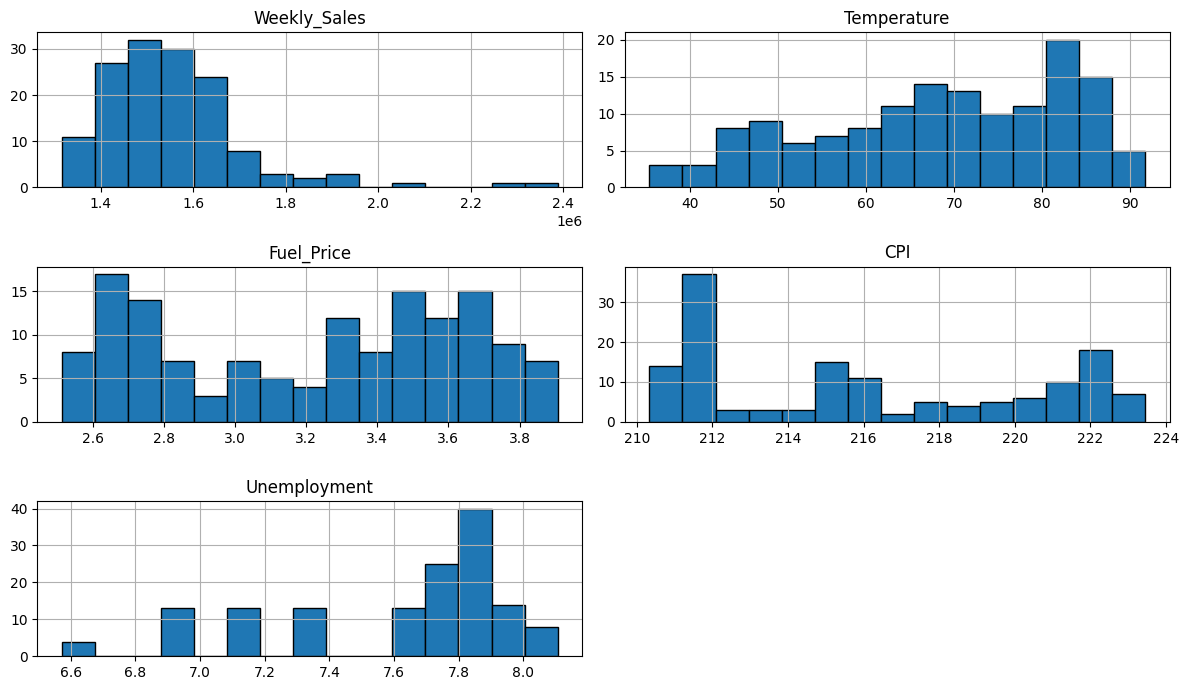

In [26]:
# plot the continuous columns to see their shape, not just their numbers
num_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
store1_df[num_cols].hist(figsize=(12, 7), bins=15, edgecolor='black')
plt.tight_layout()
plt.show()

# **Answering some questions**
## What is the time range of the dataset
-> **2 years and 9 months:** There are 143 observations recorded in the time series for Store 1, spanned by a time interval of about 2 years and 9 months, from 2010-02-05 to 2012-10-26. The target (Weekly_Sales) is only available up to the 26th of October, 2012 in train.csv, while features.csv goes through 26th July, 2013; the left-join performed in the merge step only have the labelled window. *refer to the output of code cell after Step 5: Time range and frequency*
## What is the frequency/granularity?
-> **The series were recorded on Weekly basis:** This was checked instead of assumed: ```(gaps==7).all()==True```, ```pd.infer_freq``` labels the index W-FRI, and the index is a gap-free weekly timeframe for the same time period as the data (143 out of 143 dates). The granularity of the data is such that each record is equal to one store-week: at the store × department level data is recorded and aggregated (sum) to provide the desired store-week level of data.
## Are there missing values? How did you handle the missing values, and why was that methodology selected?
-> Yes, there are some missing values. as this ```store1_df.isnull().sum()``` returned some non-zero numbers for MarkDown1-5 columns.
Prior to cleaning, missing values were confined entirely to the five promotional-markdown columns: MarkDown1 (92), MarkDown2 (101), MarkDown3 (93), MarkDown4 (92), MarkDown5 (92). Temperature, Fuel_Price, CPI, and Unemployment contained no missing values in this window.
The markdown gaps were filled with 0 (fillna(0)). This methodology was selected because the missingness is not random but structural: markdown tracking began only in November 2011, as stated in the dataset documentation and confirmed empirically — MarkDown1 is absent for the 92 consecutive weeks from 2010-02-05 to 2011-11-04, with the first recorded value on 2011-11-11. A blank therefore denotes the absence of any promotional markdown, for which 0 (the neutral "no discount" value) is the faithful representation.
## Statistical distribution of numerical columns
Referring to the output of cell after step 7, ```store1.describe()``` shows that; The Weekly_Sales distribution is highly right skewed (skew = +2.18): most of the weeks are in the range 1.46M to 1.61M with a few few outliers in the long upper tail up to 2.39M. This tail is attributable to three identifiable holiday weeks — 2010-12-24 (2.39M), 2011-12-23 (2.27M), and 2011-11-25 (2.03M) — corresponding to Christmas and Thanksgiving. The more moderate variables are: The temperature from 35°F to 92°F is more representative of the seasonal changes that take place in the store region; and the CPI variable is increasing at a relatively slow rate (left skewed, −1.06), and the Unemployment variable is decreasing from 8.11 to 6.57 (left skewed, −1.06). The 25th and 50th percentiles of the distribution of the markdown columns are both 0, because there were no weeks before November 2011, and no weeks after – this distribution is not bell-shaped; otherwise, it is zero-inflated with a long right tail only if there are promotions.

# **B. Analytical Questions**

# Q1. Does the series have an increasing/decreasing trend?

In [27]:
store1_df.head(10)

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,IsHoliday
Date,,,,,,,,,,,
2010-02-05,1643690.90,42.31,2.572,211.096358,8.106,0.0,0.0,0.0,0.0,0.0,False
2010-02-12,1641957.44,38.51,2.548,211.242170,8.106,0.0,0.0,0.0,0.0,0.0,True
2010-02-19,1611968.17,39.93,2.514,211.289143,8.106,0.0,0.0,0.0,0.0,0.0,False
2010-02-26,1409727.59,46.63,2.561,211.319643,8.106,0.0,0.0,0.0,0.0,0.0,False
2010-03-05,1554806.68,46.50,2.625,211.350143,8.106,0.0,0.0,0.0,0.0,0.0,False
2010-03-12,1439541.59,57.79,2.667,211.380643,8.106,0.0,0.0,0.0,0.0,0.0,False
2010-03-19,1472515.79,54.58,2.720,211.215635,8.106,0.0,0.0,0.0,0.0,0.0,False
2010-03-26,1404429.92,51.45,2.732,211.018042,8.106,0.0,0.0,0.0,0.0,0.0,False
2010-04-02,1594968.28,62.27,2.719,210.820450,7.808,0.0,0.0,0.0,0.0,0.0,False


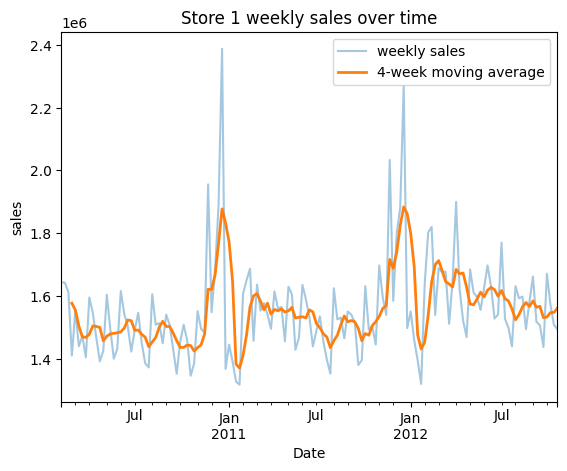

trend per year: 42007
first-year avg: 1514594 | last-year avg: 1617300


In [28]:
# smooth the noisy weekly line with a 4-week (monthly) moving average so the direction shows
store1_df['Weekly_Sales'].plot(alpha=0.4, label='weekly sales')
store1_df['Weekly_Sales'].rolling(4).mean().plot(linewidth=2, label='4-week moving average')
plt.title('Store 1 weekly sales over time'); plt.ylabel('sales'); plt.legend(); plt.show()

slope = np.polyfit(np.arange(len(store1_df)), store1_df['Weekly_Sales'], 1)[0]
print("trend per year:", round(slope * 52))
print("first-year avg:", round(store1_df['Weekly_Sales'].iloc[:52].mean()),
      "| last-year avg:", round(store1_df['Weekly_Sales'].iloc[-52:].mean()))

# Answer to question #1

-> The serie has a trend that is mildly **increasing**, Sales rise  approximately 42,000/year (first-year avg 1.51M → last-year avg 1.62M, correlation with time 0.22). Real but gentle; seasonality dominates the picture.

# Q2. Is there seasonality (do sales spike at certain times of year)?

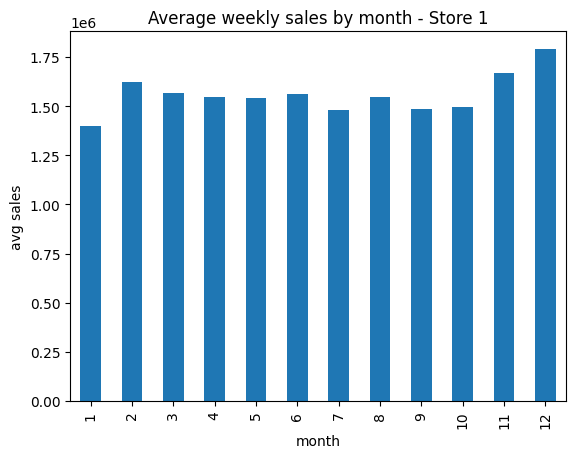

In [29]:
# average sales per calendar month to expose the yearly pattern
monthly = store1_df['Weekly_Sales'].groupby(store1_df.index.month).mean()
monthly.plot(kind='bar', title='Average weekly sales by month - Store 1')
plt.xlabel('month'); plt.ylabel('avg sales'); plt.show()

# Answer to question #2
-> **Yes**, there is a strong yearly seasonality. Sales spike every November–December (December averages ~1.79M vs a ~1.4–1.55M baseline); the top weeks are all Christmas/Thanksgiving, and holiday weeks average 1.67M vs 1.55M for normal weeks.

# Q3. Do external variables correlate with the target over time?

Temperature    -0.223
Fuel_Price      0.125
CPI             0.225
Unemployment   -0.098
dtype: float64


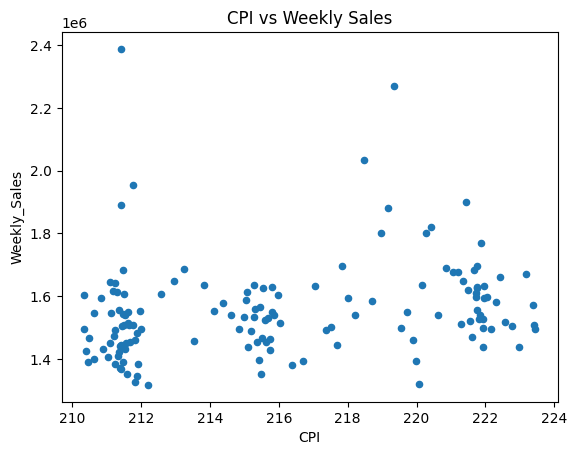

In [30]:
# correlation of each numeric predictor with the target
external = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
print(store1_df[external].apply(lambda c: c.corr(store1_df['Weekly_Sales'])).round(3))

# show the strongest one visually
store1_df.plot.scatter(x='CPI', y='Weekly_Sales', title='CPI vs Weekly Sales')
plt.show()

# Answer to question #3
-> **Barely**. All weak: CPI +0.23, Temperature −0.22, Fuel_Price +0.13, Unemployment −0.10. The economy/weather don't drive Store 1's sales, the calendar does.

# Q4. Lag effect: is this week related to previous weeks?

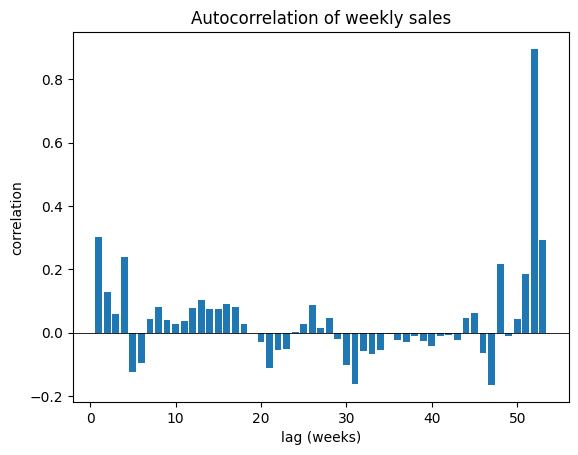

lag 1: 0.302 | lag 52: 0.895


In [31]:
# build the lag features to be reused later in the model
store1_df['sales_lag_1']  = store1_df['Weekly_Sales'].shift(1)    # last week
store1_df['sales_lag_52'] = store1_df['Weekly_Sales'].shift(52)   # same week last year

# autocorrelation across a range of lags - the tall bar tells you the rhythm
acf = [store1_df['Weekly_Sales'].corr(store1_df['Weekly_Sales'].shift(k)) for k in range(1, 54)]
plt.bar(range(1, 54), acf); plt.axhline(0, color='k', linewidth=0.6)
plt.title('Autocorrelation of weekly sales'); plt.xlabel('lag (weeks)'); plt.ylabel('correlation'); plt.show()
print("lag 1:", round(acf[0], 3), "| lag 52:", round(acf[51], 3))

# Answer to question #4
-> **Yes, but yearly, not weekly**. Autocorrelation peaks hard at lag 52 (0.895 - this week ≈ same week last year); lag 1 is only 0.30 and lags 2–3 fade to zero. The memory is annual.

# Q5. Moving average: does the recent average track sales?

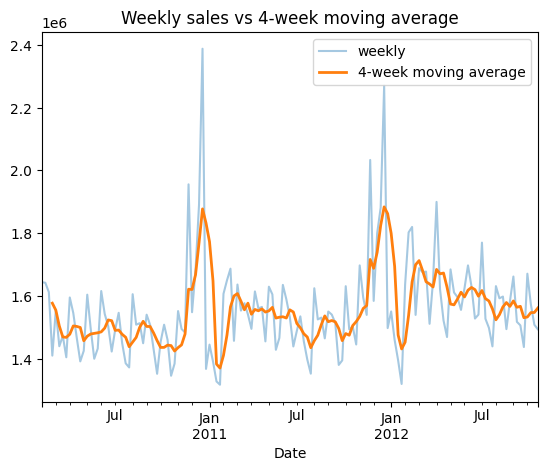

corr(sales, trailing 4-week avg): 0.29


In [32]:
# 4-week (roughly monthly) moving average
store1_df['sales_ma4'] = store1_df['Weekly_Sales'].rolling(4).mean()

# show how the moving average smooths the noise and reveals the level
store1_df['Weekly_Sales'].plot(alpha=0.4, label='weekly')
store1_df['sales_ma4'].plot(linewidth=2, label='4-week moving average')
plt.title('Weekly sales vs 4-week moving average'); plt.legend(); plt.show()

# does the average of the previous 4 weeks relate to this week? (backward-looking, no peeking)
ma4_prev = store1_df['Weekly_Sales'].rolling(4).mean().shift(1)
print("corr(sales, trailing 4-week avg):", round(store1_df['Weekly_Sales'].corr(ma4_prev), 3))

# Answer to question #5
-> **Modestly**. The trailing 4-week average correlates 0.29 with the current week, and the moving average smooths the series (std drops 156k → 100k), cleanly revealing the trend and holiday humps, but recent weeks carry far less signal than the year-ago value from Q4

# **C. Training a model**

## Step 1: build the model features
As one of the treatment of time-series data, where the great information are stored low-key inside the target variables as seen in 4 above where the lag-52 showed strong correlation

In [33]:
# lag features: last week, and the same week one year ago
store1_df['sales_lag_1']  = store1_df['Weekly_Sales'].shift(1)
store1_df['sales_lag_52'] = store1_df['Weekly_Sales'].shift(52)

# 4-week average of the weeks BEFORE this one - the shift(1) keeps the current week out
# so the feature never contains the value we're trying to predict
store1_df['sales_ma4'] = store1_df['Weekly_Sales'].rolling(4).mean().shift(1)

# lag_52 is empty for the first 52 weeks, so drop the rows that aren't fully formed
model_df = store1_df.dropna()
print("usable weeks:", len(model_df))   # 91

usable weeks: 91


In [34]:
model_df

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,IsHoliday,sales_lag_1,sales_lag_52,sales_ma4
Date,,,,,,,,,,,,,,
2011-02-04,1606629.58,42.27,2.989,212.566881,7.742,0.00,0.00,0.00,0.00,0.00,False,1316899.31,1643690.90,1.370013e+06
2011-02-11,1649614.93,36.39,3.022,212.936705,7.742,0.00,0.00,0.00,0.00,0.00,True,1606629.58,1641957.44,1.410487e+06
2011-02-18,1686842.78,57.36,3.045,213.247885,7.742,0.00,0.00,0.00,0.00,0.00,False,1649614.93,1611968.17,1.475137e+06
2011-02-25,1456800.28,62.90,3.065,213.535609,7.742,0.00,0.00,0.00,0.00,0.00,False,1686842.78,1409727.59,1.564997e+06
2011-03-04,1636263.41,59.58,3.288,213.823333,7.742,0.00,0.00,0.00,0.00,0.00,False,1456800.28,1554806.68,1.599972e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-09-28,1437059.26,76.08,3.666,222.981658,6.908,3666.27,7.64,1.65,1417.96,4744.28,False,1506126.06,1394561.83,1.566851e+06
2012-10-05,1670785.97,68.55,3.617,223.181477,6.573,8077.89,0.00,18.22,3617.43,3626.14,False,1437059.26,1630989.95,1.530595e+06
2012-10-12,1573072.81,62.99,3.601,223.381296,6.573,2086.18,0.00,8.11,602.36,5926.45,False,1670785.97,1493525.93,1.532850e+06


## Step 2: feature groups and the time-ordered split

In [35]:
exog = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday',
        'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
hist = ['sales_lag_1', 'sales_lag_52', 'sales_ma4']
y = model_df['Weekly_Sales']

# train on the past, test on the last 26 weeks - never shuffle a time series
n_test = 26
tr = slice(0, len(model_df) - n_test)
te = slice(len(model_df) - n_test, None)
print("train:", model_df.index[tr][0].date(), "->", model_df.index[tr][-1].date())
print("test :", model_df.index[te][0].date(), "->", model_df.index[te][-1].date())

train: 2011-02-04 -> 2012-04-27
test : 2012-05-04 -> 2012-10-26


In [36]:
y

,Weekly_Sales
Date,
2011-02-04,1606629.58
2011-02-11,1649614.93
2011-02-18,1686842.78
2011-02-25,1456800.28
2011-03-04,1636263.41
...,...
2012-09-28,1437059.26
2012-10-05,1670785.97
2012-10-12,1573072.81


## Step 3: metric helpers

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmse(a, b): return np.sqrt(mean_squared_error(a, b))
def mape(a, b): return (np.abs((a - b) / a)).mean() * 100   # average % error, readable at this scale

## Step 4: the two experiments (plain linear regression)

In [38]:
from sklearn.linear_model import LinearRegression

def run(cols):
    model = LinearRegression().fit(model_df[cols].iloc[tr], y.iloc[tr])
    return model.predict(model_df[cols].iloc[te])

pred_A = run(exog)          # exogenous variables only
pred_B = run(exog + hist)   # add the lag / moving-average features

## Step 5: hyperparameter tuning (Ridge, alpha picked by time-ordered CV)

In [39]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

X_all = model_df[exog + hist] # all features included

# scaler lives inside the pipeline so it's refit on each training fold - no leakage
# TimeSeriesSplit keeps the folds in time order, never random
# Ridge is linear regression with one addition: it penalizes large weights.
# How hard it penalizes is set by a number called alpha.
grid = GridSearchCV(make_pipeline(StandardScaler(), Ridge()),
                    {'ridge__alpha': [0.1, 1, 10, 100, 1000]},
                    cv=TimeSeriesSplit(n_splits=4), scoring='neg_mean_squared_error')
grid.fit(X_all.iloc[tr], y.iloc[tr])
pred_C = grid.predict(X_all.iloc[te])
print("best alpha:", grid.best_params_['ridge__alpha'])

best alpha: 10


## Step 6: build the experiment table

In [40]:
# collect every model's scores into one table
rows = []
def add(name, feats, tuning, y_pred):
    rows.append({
        'Experiment': name,
        'Features': feats,
        'Tuning': tuning,
        'RMSE': round(rmse(y.iloc[te], y_pred)),
        'MAE':  round(mean_absolute_error(y.iloc[te], y_pred)),
        'MAPE(%)': round(mape(y.iloc[te], y_pred), 2),
    })

add('Baseline: same week last year', 'sales_lag_52', '-', model_df['sales_lag_52'].iloc[te])
add('Baseline: last week',           'sales_lag_1',  '-', model_df['sales_lag_1'].iloc[te])
add('Exp A: exogenous only', 'temp, fuel, CPI, unemp, holiday, markdowns', 'none', pred_A)
add('Exp B: exogenous + history', 'Exp A + lag_1, lag_52, ma4', 'none', pred_B)
add('Exp C: Ridge (scaled)', 'all features', f"alpha={grid.best_params_['ridge__alpha']}", pred_C)

results = pd.DataFrame(rows)
results.to_csv('experiment_table.csv', index=False)   # save it for the report
results

,Experiment,Features,Tuning,RMSE,MAE,MAPE(%)
0,Baseline: same week last year,sales_lag_52,-,88398,70783,4.45
1,Baseline: last week,sales_lag_1,-,116431,91220,5.71
2,Exp A: exogenous only,"temp, fuel, CPI, unemp, holiday, markdowns",none,147051,121848,7.57
3,Exp B: exogenous + history,"Exp A + lag_1, lag_52, ma4",none,72870,58494,3.66
4,Exp C: Ridge (scaled),all features,alpha=10,55521,40288,2.51


### Results

All models are scored on the last 26 weeks. Weekly sales sit around 1.55M, so RMSE runs in the tens of thousands and MAPE (average % error) is the easier number to read.

- **Outside variables alone aren't enough.** Exp A (temperature, fuel, CPI, unemployment, holiday, markdowns) is the worst at 7.57% MAPE, even worse than reusing last year's same week (4.45%). This matches Q3: those variables barely correlate with sales.
- **The sales history is what makes it predictable.** Adding the lag and moving-average features (Exp B) drops the error to 3.66% and beats both baselines, mostly from `sales_lag_52` carrying the yearly pattern.
- **Tuning helps.** The scaled Ridge (Exp C, alpha=10) is best at 2.51% MAPE (RMSE 55,521, MAE 40,288). With only 65 training weeks, shrinking the coefficients reduces overfitting.

Two caveats: the large `Fuel_Price` coefficient is a units artifact, not importance (that's why Ridge scales the features first), and the test window (May to Oct 2012) has no holiday weeks, so these scores reflect normal-week accuracy only.

## Step 7: Evaluation

R2 on test: 0.523


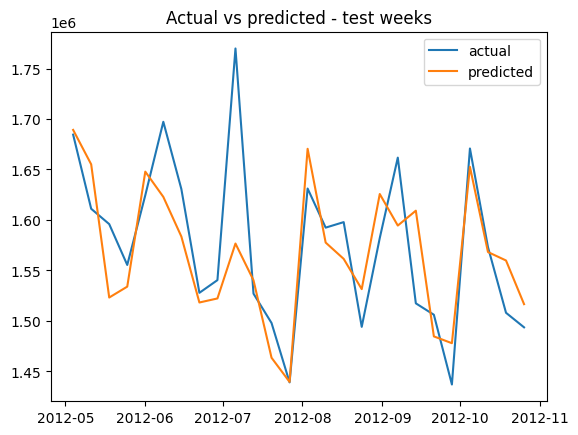

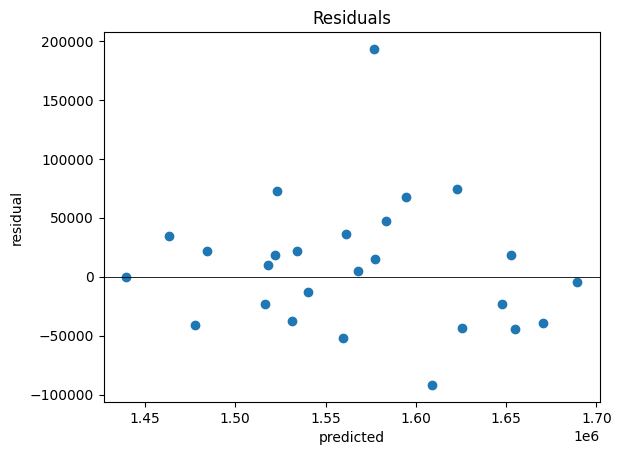

In [41]:
from sklearn.metrics import r2_score
best_model = grid.best_estimator_          # the fitted scaler + Ridge (Exp C)
pred = best_model.predict(X_all.iloc[te])

print("R2 on test:", round(r2_score(y.iloc[te], pred), 3))

# actual vs predicted across the test weeks - they should track closely
plt.plot(model_df.index[te], y.iloc[te], label='actual')
plt.plot(model_df.index[te], pred, label='predicted')
plt.legend(); plt.title('Actual vs predicted - test weeks'); plt.show()

# residuals should scatter around 0 with no trend
resid = y.iloc[te].values - pred
plt.scatter(pred, resid); plt.axhline(0, color='k', linewidth=0.6)
plt.xlabel('predicted'); plt.ylabel('residual'); plt.title('Residuals'); plt.show()

## Step 8: Saving the model with pickle

In [42]:
import pickle

bundle = {
    'model': grid.best_estimator_,
    'features': exog + hist,   # exact column order the model expects
}
with open('store1_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)